In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/cleaned_grievances.csv"
)

df.head()

,complaint,department,sentiment,cleaned_text
0,Water supply not available for 3 days,Water,Critical,water supply available day
1,Street light not working,Roads,Negative,street light work
2,Power outage in sector 10,Electricity,Critical,power outage sector
3,Garbage not collected for a week,Sanitation,Negative,garbage collect week
4,Water leakage near main road,Water,Negative,water leakage near main road


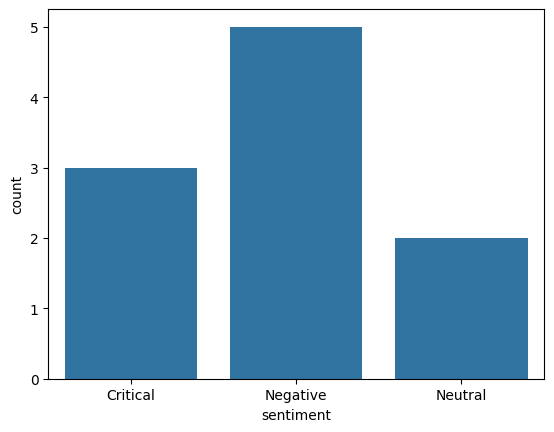

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="sentiment"
)

plt.show()

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df["cleaned_text"]
)

y = df["sentiment"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
from sklearn.linear_model import LogisticRegression

sentiment_model = LogisticRegression(
    max_iter=1000
)

sentiment_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
accuracy = sentiment_model.score(
    X_test,
    y_test
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.5


In [7]:
predictions = sentiment_model.predict(
    X_test
)

print(predictions[:10])

['Negative' 'Negative']


In [8]:
import joblib

joblib.dump(
    sentiment_model,
    "../models/sentiment_model.pkl"
)

print("Sentiment Model Saved")

Sentiment Model Saved


In [9]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [10]:
result = classifier(
    "Water supply not available for 3 days"
)

print(result)

[{'label': 'NEGATIVE', 'score': 0.9953872561454773}]


In [11]:
urgent_keywords = [
    "urgent",
    "emergency",
    "critical",
    "danger",
    "accident",
    "hospital",
    "fire",
    "flood"
]

In [12]:
def detect_urgency(text):

    text = text.lower()

    for keyword in urgent_keywords:

        if keyword in text:
            return "Critical"

    return "Normal"

In [13]:
complaint = """
Emergency water pipeline burst
near hospital area
"""

print(
    detect_urgency(
        complaint
    )
)

Critical


In [14]:
def calculate_priority(sentiment):

    if sentiment == "Critical":
        return 100

    elif sentiment == "Negative":
        return 75

    elif sentiment == "Neutral":
        return 50

    return 25

In [15]:
df["priority_score"] = df[
    "sentiment"
].apply(
    calculate_priority
)

df.head()

,complaint,department,sentiment,cleaned_text,priority_score
0,Water supply not available for 3 days,Water,Critical,water supply available day,100
1,Street light not working,Roads,Negative,street light work,75
2,Power outage in sector 10,Electricity,Critical,power outage sector,100
3,Garbage not collected for a week,Sanitation,Negative,garbage collect week,75
4,Water leakage near main road,Water,Negative,water leakage near main road,75


In [16]:
df.to_csv(
    "../data/processed/sentiment_results.csv",
    index=False
)

print(
    "Results Saved"
)

Results Saved


In [17]:
sample = """
Water supply not available
for 3 days
"""

sample_vector = vectorizer.transform(
    [sample]
)

prediction = sentiment_model.predict(
    sample_vector
)

print(
    prediction
)

['Critical']
